# FL-MTKD with DFT Reparameterization -- COVID-19 CT Scans

With fair compression measurement.

## What changed from the original notebook
1. **Fair entropy measurement**: `estimate_fair_compression()` runs the entropy model
   on **reconstructed spatial-domain weights** (the actual values used at inference),
   not on the raw `theta` coefficients. The original measured only `theta`, ignoring
   the information carried by `log_scales`.
2. **Ground-truth gzip measurement**: `estimate_gzip_compression()` serializes the
   transmittable weight arrays and compresses them with gzip to give an
   implementation-independent reference.
3. Both the original (theta-only) and corrected (fair) metrics are reported so
   you can see the gap.

Based on: Oktay et al., "Scalable Model Compression by Entropy Penalized Reparameterization" (ICLR 2020)

In [1]:
import tensorflow as tf
from tensorflow.keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
import json, os, gzip, io
from pathlib import Path
from sklearn.model_selection import train_test_split

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {len(gpus)}")

2026-04-12 14:20:03.832634: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-12 14:20:04.132186: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-12 14:20:05.541662: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow: 2.13.0
GPUs: 4


## 1. Configuration (Matched to FL_MTKD_with_compression)

In [2]:
IMAGE_SIZE = 200
NUM_CLASSES = 2
BATCH_SIZE = 16
NUM_EPOCHS = 2
NUM_ROUNDS = 50
NUM_CLIENTS = 3

LAMBDA_RATE = 0.00001
LEARNING_RATE = 0.001
TEMPERATURE = 10.0
ALPHA = 0.6

CLASSES = ['COVID-19', 'Non-COVID-19']
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 1)

TEACHER_WEIGHTS = np.array([
    [1.7, 0.85, 0.85],
    [0.6, 1.2, 0.6],
    [0.80, 0.80, 1.6]
], dtype='float32')
TEACHER_WEIGHTS = TEACHER_WEIGHTS / TEACHER_WEIGHTS.sum(axis=1, keepdims=True)

print("Configuration:")
print(f"  Alpha: {ALPHA}, Temperature: {TEMPERATURE}, Lambda: {LAMBDA_RATE}")
print(f"  Rounds: {NUM_ROUNDS}, Clients: {NUM_CLIENTS}, Epochs/round: {NUM_EPOCHS}")
print(f"  Teacher weights (normalized):\n{TEACHER_WEIGHTS}")

Configuration:
  Alpha: 0.6, Temperature: 10.0, Lambda: 1e-05
  Rounds: 50, Clients: 3, Epochs/round: 2
  Teacher weights (normalized):
[[0.5  0.25 0.25]
 [0.25 0.5  0.25]
 [0.25 0.25 0.5 ]]


## 2. Load COVID-19 CT Scan Data

In [3]:
possible_base_paths = [
    Path('/home/maxwellsam/Compression_Model_FL_MTKD/data'),
    Path('/Users/maxwellsam/Documents/FL_MTKD-Compression/data'),
    Path('./data'),
    Path('../data'),
]

def find_data_path():
    for base_path in possible_base_paths:
        if (base_path / 'Dataset1' / 'Dataset1_input.npy').exists():
            print(f"Found data at: {base_path}")
            return base_path
    print("Could not find data.")
    return None

DATA_PATH = find_data_path()
if DATA_PATH is None:
    raise FileNotFoundError("Data not found. Update possible_base_paths.")

Found data at: /home/maxwellsam/Compression_Model_FL_MTKD/data


In [4]:
print("Loading COVID-19 CT scan datasets...")

input_data_x_load = np.load(str(DATA_PATH / 'Dataset1' / 'Dataset1_input.npy'))
output_label_y_load = np.load(str(DATA_PATH / 'Dataset1' / 'Dataset1_output.npy'))

input_data_x_2_load = np.load(str(DATA_PATH / 'Dataset2' / 'Dataset2_input.npy'))
output_label_y_2_load = np.load(str(DATA_PATH / 'Dataset2' / 'Dataset2_output.npy'))

input_data_x_3_load = np.load(str(DATA_PATH / 'Dataset3' / 'Dataset3_input.npy'))
output_label_y_3_load = np.load(str(DATA_PATH / 'Dataset3' / 'Dataset3_output.npy'))

print(f'Dataset 1: X={input_data_x_load.shape}, Y={output_label_y_load.shape}')
print(f'Dataset 2: X={input_data_x_2_load.shape}, Y={output_label_y_2_load.shape}')
print(f'Dataset 3: X={input_data_x_3_load.shape}, Y={output_label_y_3_load.shape}')

Loading COVID-19 CT scan datasets...
Dataset 1: X=(4649, 200, 200, 1), Y=(4649, 2)
Dataset 2: X=(13980, 200, 200, 1), Y=(13980, 2)
Dataset 3: X=(13808, 200, 200, 1), Y=(13808, 2)


In [5]:
print("Creating federated client datasets (Non-IID Unbalanced)...")

train_features_dataset1_fed, test_features_dataset1_fed, train_labels_dataset1_fed, test_labels_dataset1_fed = train_test_split(
    input_data_x_load[2501:3901,:], output_label_y_load[2501:3901,:], test_size=.20, random_state=25)

train_features_dataset2_fed, test_features_dataset2_fed, train_labels_dataset2_fed, test_labels_dataset2_fed = train_test_split(
    input_data_x_2_load[6501:10400,:], output_label_y_2_load[6501:10400,:], test_size=.20, random_state=25)

train_features_dataset3_fed, test_features_dataset3_fed, train_labels_dataset3_fed, test_labels_dataset3_fed = train_test_split(
    input_data_x_3_load[1201:,:], output_label_y_3_load[1201:,:], test_size=.20, random_state=25)

print(f'Client 1: train={train_features_dataset1_fed.shape}, test={test_features_dataset1_fed.shape}')
print(f'Client 2: train={train_features_dataset2_fed.shape}, test={test_features_dataset2_fed.shape}')
print(f'Client 3: train={train_features_dataset3_fed.shape}, test={test_features_dataset3_fed.shape}')

x_test_combined = np.concatenate((test_features_dataset1_fed, test_features_dataset2_fed, test_features_dataset3_fed), axis=0)
y_test_combined = np.concatenate((test_labels_dataset1_fed, test_labels_dataset2_fed, test_labels_dataset3_fed), axis=0)
print(f'Combined test set: {x_test_combined.shape}')

Creating federated client datasets (Non-IID Unbalanced)...
Client 1: train=(1120, 200, 200, 1), test=(280, 200, 200, 1)
Client 2: train=(3119, 200, 200, 1), test=(780, 200, 200, 1)
Client 3: train=(10085, 200, 200, 1), test=(2522, 200, 200, 1)
Combined test set: (3582, 200, 200, 1)


In [6]:
client_data = [
    (train_features_dataset1_fed, train_labels_dataset1_fed),
    (train_features_dataset2_fed, train_labels_dataset2_fed),
    (train_features_dataset3_fed, train_labels_dataset3_fed)
]

def create_tf_dataset_for_client(client_dataset):
    return tf.data.Dataset.from_tensor_slices(client_dataset)

def preprocess_dataset(dataset, batch_size=BATCH_SIZE):
    return dataset.shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

client_datasets = [create_tf_dataset_for_client(data) for data in client_data]
federated_train_data = [preprocess_dataset(ds) for ds in client_datasets]

print(f"Created {len(federated_train_data)} federated client datasets")

2026-04-12 14:20:12.181778: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14755 MB memory:  -> device: 0, name: Quadro RTX 5000, pci bus id: 0000:19:00.0, compute capability: 7.5
2026-04-12 14:20:12.182429: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14755 MB memory:  -> device: 1, name: Quadro RTX 5000, pci bus id: 0000:1a:00.0, compute capability: 7.5
2026-04-12 14:20:12.182918: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14755 MB memory:  -> device: 2, name: Quadro RTX 5000, pci bus id: 0000:67:00.0, compute capability: 7.5
2026-04-12 14:20:12.183337: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 14149 MB memory:  -> device: 3, name: Quadro RTX 5000, pci bus id: 0000:68:00.0, comp

Created 3 federated client datasets


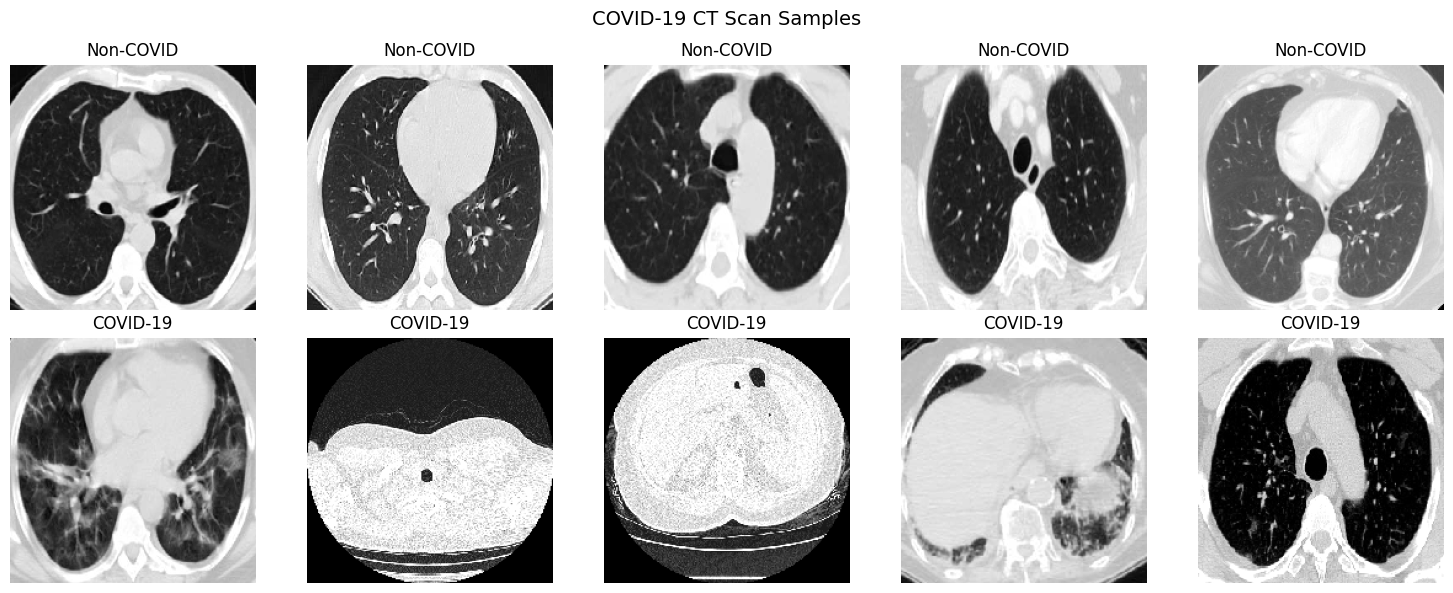

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
combined_train_x = np.concatenate([d[0] for d in client_data])
combined_train_y = np.concatenate([d[1] for d in client_data])

class_0_idx = np.where(combined_train_y[:, 0] == 1)[0][:5]
class_1_idx = np.where(combined_train_y[:, 1] == 1)[0][:5]

for i in range(min(5, len(class_0_idx))):
    img = combined_train_x[class_0_idx[i]]
    if len(img.shape) == 3: img = img[:,:,0]
    axes[0, i].imshow(img, cmap='gray'); axes[0, i].set_title('Non-COVID'); axes[0, i].axis('off')

for i in range(min(5, len(class_1_idx))):
    img = combined_train_x[class_1_idx[i]]
    if len(img.shape) == 3: img = img[:,:,0]
    axes[1, i].imshow(img, cmap='gray'); axes[1, i].set_title('COVID-19'); axes[1, i].axis('off')

plt.suptitle('COVID-19 CT Scan Samples', fontsize=14)
plt.tight_layout(); plt.show()

## 3. DFT Reparameterization Layers

In [8]:
class EntropyModel(tf.keras.layers.Layer):
    """Learned entropy model for estimating rate (bits) of latent parameters."""

    def __init__(self, num_filters=3, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self._built = False

    def build(self, input_shape):
        if self._built:
            return
        self.H, self.b, self.a = [], [], []
        filters = [1, self.num_filters, self.num_filters, self.num_filters, 1]
        for i in range(len(filters) - 1):
            init = tf.initializers.RandomUniform(minval=-0.5, maxval=0.5)
            self.H.append(self.add_weight(name=f'H_{i}', shape=(filters[i+1], filters[i]),
                                          initializer=init, trainable=False))
            self.b.append(self.add_weight(name=f'b_{i}', shape=(filters[i+1], 1),
                                          initializer='zeros', trainable=False))
            if i < len(filters) - 2:
                self.a.append(self.add_weight(name=f'a_{i}', shape=(filters[i+1], 1),
                                              initializer='zeros', trainable=False))
        self._built = True
        super().build(input_shape)

    def _logits_cumulative(self, x):
        x = tf.reshape(x, (1, -1))
        for i, (H, b) in enumerate(zip(self.H, self.b)):
            x = tf.nn.softplus(H) @ x + b
            if i < len(self.a):
                x = x + tf.tanh(self.a[i]) * tf.tanh(x)
        return tf.squeeze(x, axis=0)

    def call(self, x, training=False):
        if not self._built:
            self.build(x.shape)
        x_flat = tf.reshape(x, [-1])
        if training:
            x_flat = x_flat + tf.random.uniform(tf.shape(x_flat), -0.5, 0.5)
        lower = self._logits_cumulative(x_flat - 0.5)
        upper = self._logits_cumulative(x_flat + 0.5)
        sign = tf.stop_gradient(tf.sign(lower + upper))
        sign = tf.where(tf.equal(sign, 0), tf.ones_like(sign), sign)
        likelihood = tf.abs(tf.sigmoid(sign * upper) - tf.sigmoid(sign * lower))
        likelihood = tf.maximum(likelihood, 1e-9)
        bits = -tf.math.log(likelihood) / tf.math.log(2.0)
        return tf.reduce_sum(bits)

In [9]:
def create_dft_matrix(n):
    """Create real-valued DFT basis matrix."""
    i = tf.range(n, dtype=tf.float32)
    j = tf.range(n, dtype=tf.float32)
    freq = 2.0 * np.pi * tf.reshape(i, [-1, 1]) * tf.reshape(j, [1, -1]) / tf.cast(n, tf.float32)
    dft_matrix = tf.cos(freq) / tf.sqrt(tf.cast(n, tf.float32))
    dft_matrix = dft_matrix / (tf.norm(dft_matrix, axis=1, keepdims=True) + 1e-8)
    return dft_matrix


class DFTConv2D(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, activation=None, lambda_rate=0.001, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.activation = tf.keras.activations.get(activation)
        self.lambda_rate = lambda_rate

    def build(self, input_shape):
        in_channels = input_shape[-1]
        kh, kw = self.kernel_size
        self.kernel_shape = (kh, kw, in_channels, self.filters)
        self.num_params = kh * kw * in_channels * self.filters

        self.theta = self.add_weight(name='theta', shape=(self.num_params,),
                                     initializer='glorot_normal', trainable=True)
        self.log_scales = self.add_weight(name='log_scales', shape=(self.num_params,),
                                          initializer=tf.initializers.Constant(-1.0), trainable=True)
        self.bias = self.add_weight(name='bias', shape=(self.filters,),
                                    initializer='zeros', trainable=True)
        self.dft_h = create_dft_matrix(kh)
        self.dft_w = create_dft_matrix(kw)
        self.entropy_model = EntropyModel()
        self.entropy_model.build((self.num_params,))
        super().build(input_shape)

    def get_kernel(self):
        scales = tf.exp(self.log_scales)
        scaled_theta = scales * self.theta
        theta_4d = tf.reshape(scaled_theta, self.kernel_shape)
        kernel = tf.tensordot(tf.transpose(self.dft_h), theta_4d, axes=[[1], [0]])
        kernel = tf.tensordot(tf.transpose(self.dft_w), kernel, axes=[[1], [1]])
        kernel = tf.transpose(kernel, [1, 0, 2, 3])
        return kernel

    def get_reconstructed_weights_flat(self):
        """Return the spatial-domain weights as a flat vector (what inference actually uses)."""
        return tf.reshape(self.get_kernel(), [-1])

    def compute_entropy_loss(self):
        bits = self.entropy_model(self.theta, training=True)
        return self.lambda_rate * bits

    def call(self, inputs, training=False):
        kernel = self.get_kernel()
        output = tf.nn.conv2d(inputs, kernel, strides=1, padding='VALID')
        output = tf.nn.bias_add(output, self.bias)
        if self.activation is not None:
            output = self.activation(output)
        return output


class DFTDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, lambda_rate=0.001, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.lambda_rate = lambda_rate

    def build(self, input_shape):
        in_features = input_shape[-1]
        self.num_params = in_features * self.units
        self.weight_shape = (in_features, self.units)

        self.theta = self.add_weight(name='theta', shape=(self.num_params,),
                                     initializer='glorot_normal', trainable=True)
        self.log_scales = self.add_weight(name='log_scales', shape=(self.num_params,),
                                          initializer=tf.initializers.Constant(-1.0), trainable=True)
        self.bias = self.add_weight(name='bias', shape=(self.units,),
                                    initializer='zeros', trainable=True)
        self.entropy_model = EntropyModel()
        self.entropy_model.build((self.num_params,))
        super().build(input_shape)

    def get_kernel(self):
        scales = tf.exp(self.log_scales)
        scaled_theta = scales * self.theta
        return tf.reshape(scaled_theta, self.weight_shape)

    def get_reconstructed_weights_flat(self):
        return tf.reshape(self.get_kernel(), [-1])

    def compute_entropy_loss(self):
        bits = self.entropy_model(self.theta, training=True)
        return self.lambda_rate * bits

    def call(self, inputs, training=False):
        kernel = self.get_kernel()
        output = tf.matmul(inputs, kernel) + self.bias
        if self.activation is not None:
            output = self.activation(output)
        return output

## 4. Create DFT Student Model

In [10]:
def create_dft_student_model(lambda_rate=LAMBDA_RATE):
    inputs = tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))
    x = DFTConv2D(32, kernel_size=3, activation='relu',
                  lambda_rate=lambda_rate, name='dft_conv')(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = tf.keras.layers.Flatten()(x)
    x = DFTDense(NUM_CLASSES, lambda_rate=lambda_rate, name='dft_dense')(x)
    outputs = tf.keras.layers.Softmax()(x)
    return tf.keras.Model(inputs, outputs, name='dft_student_covid19')

test_model = create_dft_student_model()
test_model.summary()
print(f"\nInput shape: {(IMAGE_SIZE, IMAGE_SIZE, 1)}")
print(f"Output classes: {NUM_CLASSES}")

Model: "dft_student_covid19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 1)]     0         
                                                                 
 dft_conv (DFTConv2D)        (None, 198, 198, 32)      651       
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 313632)            0         
                                                                 
 dft_dense (DFTDense)        (None, 2)                 1254573   
                                                                 
 softmax (Softmax)           (None, 2)                 0         
                                               

## 5. Load Pre-trained Teacher Models

In [11]:
import time

BASE_PATH = Path('/home/maxwellsam/Compression_Model_FL_MTKD')

print("Loading pre-trained teacher models...\n", flush=True)

t0 = time.time()
print("  [1/3] teacher_CNN...", end='', flush=True)
teacher_CNN = tf.keras.models.load_model(str(BASE_PATH / 'teacher_CNN_model.h5'), compile=False)
print(f" done ({time.time()-t0:.1f}s) | {teacher_CNN.count_params():,} params", flush=True)

t0 = time.time()
print("  [2/3] Deep_COVID (SavedModel)...", end='', flush=True)
Deep_COVID_teacher = tf.saved_model.load(str(BASE_PATH / 'Deep_COVID_teacher_saved'))
print(f" done ({time.time()-t0:.1f}s)", flush=True)

t0 = time.time()
print("  [3/3] VGG16 (SavedModel)...", end='', flush=True)
VGG16_teacher = tf.saved_model.load(str(BASE_PATH / 'CNN_Mod_VGG16_teacher_saved'))
print(f" done ({time.time()-t0:.1f}s)", flush=True)

teachers = [teacher_CNN, Deep_COVID_teacher, VGG16_teacher]
teacher_params = teacher_CNN.count_params()
print(f"\nTeacher params (CNN baseline): {teacher_params:,}")

print("\nLoading pre-trained student model...", end='', flush=True)
student_reference = tf.keras.models.load_model(str(BASE_PATH / 'student_CNN_model.h5'), compile=False)
print(" done", flush=True)
student_reference.summary()
student_ref_params = student_reference.count_params()
print(f"\nStudent reference params: {student_ref_params:,}")

print("\nLoading original FL-MTKD model...", end='', flush=True)
original_fl_mtkd = tf.keras.models.load_model(str(BASE_PATH / 'gsm_noniid_unbalanced.h5'), compile=False)
print(f" done | {original_fl_mtkd.count_params():,} params", flush=True)

Loading pre-trained teacher models...

  [1/3] teacher_CNN... done (0.6s) | 5,151,065 params
  [2/3] Deep_COVID (SavedModel)... done (16.9s)
  [3/3] VGG16 (SavedModel)... done (0.5s)

Teacher params (CNN baseline): 5,151,065

Loading pre-trained student model... done
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 198, 198, 32)      320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 99, 99, 32)        0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 313632)            0         
                                                                 
 dense_12 (Dense)            (None, 2)                 627266    
                                                  

## 6. Knowledge Distillation with DFT Compression

In [12]:
class DFTCompressedDistiller:
    def __init__(self, student, teachers, optimizer, alpha=ALPHA,
                 temperature=TEMPERATURE, lambda_rate=LAMBDA_RATE,
                 teacher_weights=None):
        self.student = student
        self.teachers = teachers
        self.optimizer = optimizer
        self.alpha = alpha
        self.temperature = temperature
        self.lambda_rate = lambda_rate
        if teacher_weights is None:
            self.teacher_weights = [1.0 / len(self.teachers)] * len(self.teachers)
        else:
            self.teacher_weights = teacher_weights
        self.student_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
        self.distillation_loss_fn = tf.keras.losses.KLDivergence()

    def compute_total_entropy_loss(self):
        total = 0.0
        for layer in self.student.layers:
            if hasattr(layer, 'compute_entropy_loss'):
                total += layer.compute_entropy_loss()
        return total

    def distillation_step(self, x, y):
        with tf.GradientTape() as tape:
            student_pred = self.student(x, training=True)
            with tf.device('/CPU:0'):
                teacher_preds = [teacher(x, training=False) for teacher in self.teachers]
            ensemble_pred = sum(w * p for w, p in zip(self.teacher_weights, teacher_preds))
            soft_student = tf.nn.softmax(tf.math.log(student_pred + 1e-7) / self.temperature)
            soft_teacher = tf.nn.softmax(tf.math.log(ensemble_pred + 1e-7) / self.temperature)
            ce_loss = self.student_loss_fn(y, student_pred)
            kd_loss = self.distillation_loss_fn(soft_teacher, soft_student) * (self.temperature ** 2)
            entropy_loss = self.compute_total_entropy_loss()
            total_loss = self.alpha * ce_loss + (1 - self.alpha) * kd_loss + entropy_loss
        gradients = tape.gradient(total_loss, self.student.trainable_variables)
        gradients = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gradients]
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))
        return {'total_loss': total_loss, 'ce_loss': ce_loss, 'kd_loss': kd_loss, 'entropy_loss': entropy_loss}

## 7. Weight Management and Compression Utilities

### Three compression metrics
1. **Theta-only entropy** (original, biased): entropy model on `theta` only, ignores `log_scales`
2. **Fair entropy** (corrected): entropy model on reconstructed spatial-domain weights + counts `log_scales` and biases
3. **Gzip** (ground truth): actual gzip compression of all transmittable float32 arrays

In [13]:
def get_main_weights(model):
    weights = []
    for layer in model.layers:
        if hasattr(layer, 'theta'):
            weights.append(layer.theta.numpy())
            weights.append(layer.log_scales.numpy())
            weights.append(layer.bias.numpy())
    return weights


def set_main_weights(model, weights):
    idx = 0
    for layer in model.layers:
        if hasattr(layer, 'theta'):
            layer.theta.assign(weights[idx])
            layer.log_scales.assign(weights[idx + 1])
            layer.bias.assign(weights[idx + 2])
            idx += 3


def initialize_dft_from_student_average(dft_model, student_models):
    conv_kernels, conv_biases = [], []
    dense_kernels, dense_biases = [], []
    for student in student_models:
        for layer in student.layers:
            if isinstance(layer, tf.keras.layers.Conv2D):
                conv_kernels.append(layer.kernel.numpy())
                conv_biases.append(layer.bias.numpy())
            elif isinstance(layer, tf.keras.layers.Dense):
                dense_kernels.append(layer.kernel.numpy())
                dense_biases.append(layer.bias.numpy())
    avg_conv_kernel = np.mean(conv_kernels, axis=0)
    avg_conv_bias = np.mean(conv_biases, axis=0)
    avg_dense_kernel = np.mean(dense_kernels, axis=0)
    avg_dense_bias = np.mean(dense_biases, axis=0)

    for layer in dft_model.layers:
        if isinstance(layer, DFTConv2D):
            dft_h = layer.dft_h.numpy()
            dft_w = layer.dft_w.numpy()
            theta_4d = np.tensordot(dft_h, avg_conv_kernel, axes=[[1], [0]])
            theta_4d = np.tensordot(dft_w, theta_4d, axes=[[1], [1]])
            theta_4d = np.transpose(theta_4d, [1, 0, 2, 3])
            theta_flat = theta_4d.flatten()
            layer.theta.assign(theta_flat)
            layer.log_scales.assign(np.zeros_like(theta_flat))
            layer.bias.assign(avg_conv_bias)
            print(f"  Conv2D: warm-started {len(theta_flat)} DFT params")
        elif isinstance(layer, DFTDense):
            theta_flat = avg_dense_kernel.flatten()
            layer.theta.assign(theta_flat)
            layer.log_scales.assign(np.zeros_like(theta_flat))
            layer.bias.assign(avg_dense_bias)
            print(f"  Dense: warm-started {len(theta_flat)} DFT params")


# ─────────────────────────────────────────────────────────────────────
# METRIC 1: Original theta-only entropy (biased -- kept for reference)
# ─────────────────────────────────────────────────────────────────────
def estimate_theta_only_entropy(model):
    """Original (biased) measurement: entropy on theta only, ignoring log_scales."""
    total_bits = 0
    total_params = 0
    for layer in model.layers:
        if hasattr(layer, 'theta') and hasattr(layer, 'entropy_model'):
            bits = layer.entropy_model(layer.theta, training=False)
            total_bits += bits.numpy()
            total_params += tf.size(layer.theta).numpy()
    original_bits = total_params * 32
    return {
        'total_bits': float(total_bits),
        'original_bits': float(original_bits),
        'compression_ratio': float(original_bits / max(total_bits, 1)),
        'bits_per_param': float(total_bits / max(total_params, 1)),
        'original_size_kb': float(original_bits / 8 / 1024),
        'compressed_size_kb': float(total_bits / 8 / 1024),
        'total_params': int(total_params),
    }


# ─────────────────────────────────────────────────────────────────────
# METRIC 2: Fair entropy on reconstructed weights (corrected)
# ─────────────────────────────────────────────────────────────────────
def estimate_fair_compression(model):
    """
    Fair measurement: run entropy model on the reconstructed spatial-domain
    weights (what inference/transmission actually needs). Also counts
    log_scales and biases in the total parameter budget.
    """
    total_bits = 0
    total_params_all = 0  # theta + log_scales + bias (everything transmitted)

    for layer in model.layers:
        if hasattr(layer, 'get_reconstructed_weights_flat') and hasattr(layer, 'entropy_model'):
            reconstructed = layer.get_reconstructed_weights_flat()
            bits = layer.entropy_model(reconstructed, training=False)
            total_bits += bits.numpy()
            # Count ALL transmitted params: theta + log_scales + bias
            total_params_all += tf.size(layer.theta).numpy()
            total_params_all += tf.size(layer.log_scales).numpy()
            total_params_all += tf.size(layer.bias).numpy()

    original_bits = total_params_all * 32
    return {
        'total_bits': float(total_bits),
        'original_bits': float(original_bits),
        'compression_ratio': float(original_bits / max(total_bits, 1)),
        'bits_per_param': float(total_bits / max(total_params_all, 1)),
        'original_size_kb': float(original_bits / 8 / 1024),
        'compressed_size_kb': float(total_bits / 8 / 1024),
        'total_params': int(total_params_all),
    }


# ─────────────────────────────────────────────────────────────────────
# METRIC 3: Gzip ground truth (implementation-independent)
# ─────────────────────────────────────────────────────────────────────
def estimate_gzip_compression(model):
    """
    Serialize all transmittable weight arrays to bytes and gzip them.
    This gives an implementation-independent compression baseline.
    """
    weight_arrays = get_main_weights(model)  # theta, log_scales, bias per layer
    buf = io.BytesIO()
    for w in weight_arrays:
        buf.write(w.astype(np.float32).tobytes())
    raw_bytes = buf.getvalue()
    compressed = gzip.compress(raw_bytes, compresslevel=9)

    original_kb = len(raw_bytes) / 1024
    compressed_kb = len(compressed) / 1024
    cr = len(raw_bytes) / max(len(compressed), 1)
    bw_reduction = (1 - len(compressed) / len(raw_bytes)) * 100

    return {
        'original_size_kb': original_kb,
        'compressed_size_kb': compressed_kb,
        'compression_ratio': cr,
        'bandwidth_reduction': bw_reduction,
    }


def client_update_dft(client_id, dataset, server_weights, teachers,
                      teacher_weights_row, num_epochs=NUM_EPOCHS):
    client_model = create_dft_student_model(lambda_rate=LAMBDA_RATE)
    _ = client_model(tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 1)))
    set_main_weights(client_model, server_weights)
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    distiller = DFTCompressedDistiller(
        student=client_model, teachers=teachers, optimizer=optimizer,
        alpha=ALPHA, temperature=TEMPERATURE, lambda_rate=LAMBDA_RATE,
        teacher_weights=teacher_weights_row.tolist())
    epoch_losses = []
    for epoch in range(num_epochs):
        batch_losses = []
        for batch in dataset:
            x, y = batch
            x = tf.cast(x, tf.float32) / 255.0
            y = tf.cast(y, tf.float32)
            if len(x.shape) == 3: x = tf.expand_dims(x, -1)
            losses = distiller.distillation_step(x, y)
            batch_losses.append(losses['total_loss'].numpy())
        epoch_losses.append(np.mean(batch_losses))
    return {
        'final_weights': get_main_weights(client_model),
        'mean_loss': np.mean(epoch_losses),
    }


def server_aggregate(client_results, current_weights):
    num_clients = len(client_results)
    avg_weights = []
    for w_idx in range(len(current_weights)):
        weight_sum = np.zeros_like(current_weights[w_idx])
        for r in client_results:
            weight_sum += r['final_weights'][w_idx]
        avg_weights.append(weight_sum / num_clients)
    return avg_weights


def evaluate_model(model, test_data, test_labels):
    x_test = test_data.astype(np.float32) / 255.0
    if len(x_test.shape) == 3: x_test = np.expand_dims(x_test, -1)
    y_test = test_labels.astype(np.float32)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    return loss, acc


print("All utilities defined (3 compression metrics: theta-only, fair, gzip).")

All utilities defined (3 compression metrics: theta-only, fair, gzip).


## 8. Run Federated Training

In [14]:
global_model = create_dft_student_model(lambda_rate=LAMBDA_RATE)
_ = global_model(tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 1)))

print("Initializing DFT global model from pre-trained student weights...")
initialize_dft_from_student_average(global_model, [student_reference])

global_weights = get_main_weights(global_model)
print(f"\nWeight arrays: {len(global_weights)}")
for i, w in enumerate(global_weights):
    print(f"  [{i}] shape {w.shape}")

initial_loss, initial_acc = evaluate_model(global_model, x_test_combined, y_test_combined)
print(f"\nWarm-started model -- Loss: {initial_loss:.4f}, Accuracy: {initial_acc*100:.2f}%")

theta_stats = estimate_theta_only_entropy(global_model)
fair_stats = estimate_fair_compression(global_model)
gzip_stats = estimate_gzip_compression(global_model)

print(f"\nInitial compression:")
print(f"  Theta-only entropy CR:  {theta_stats['compression_ratio']:.2f}x (biased)")
print(f"  Fair entropy CR:        {fair_stats['compression_ratio']:.2f}x")
print(f"  Gzip CR:                {gzip_stats['compression_ratio']:.2f}x")

2026-04-12 14:20:33.258181: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8700
2026-04-12 14:20:34.921283: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Initializing DFT global model from pre-trained student weights...
  Conv2D: warm-started 288 DFT params
  Dense: warm-started 627264 DFT params

Weight arrays: 6
  [0] shape (288,)
  [1] shape (288,)
  [2] shape (32,)
  [3] shape (627264,)
  [4] shape (627264,)
  [5] shape (2,)

Warm-started model -- Loss: 0.6653, Accuracy: 57.96%

Initial compression:
  Theta-only entropy CR:  313.18x (biased)
  Fair entropy CR:        626.32x
  Gzip CR:                2.14x


In [15]:
history = {
    'round': [], 'loss': [], 'accuracy': [],
    'cr_theta_only': [], 'cr_fair': [], 'cr_gzip': [],
    'bpp_theta_only': [], 'bpp_fair': [],
}

print("\n" + "="*70)
print("FEDERATED TRAINING WITH DFT COMPRESSION ON COVID-19 CT SCANS")
print("="*70)

for round_num in range(NUM_ROUNDS):
    client_results = []
    for client_id, client_dataset in enumerate(federated_train_data):
        result = client_update_dft(
            client_id=client_id, dataset=client_dataset,
            server_weights=global_weights, teachers=teachers,
            teacher_weights_row=TEACHER_WEIGHTS[client_id])
        client_results.append(result)

    global_weights = server_aggregate(client_results, global_weights)
    set_main_weights(global_model, global_weights)

    loss, accuracy = evaluate_model(global_model, x_test_combined, y_test_combined)
    theta_stats = estimate_theta_only_entropy(global_model)
    fair_stats = estimate_fair_compression(global_model)
    gzip_stats = estimate_gzip_compression(global_model)

    history['round'].append(round_num + 1)
    history['loss'].append(loss)
    history['accuracy'].append(accuracy)
    history['cr_theta_only'].append(theta_stats['compression_ratio'])
    history['cr_fair'].append(fair_stats['compression_ratio'])
    history['cr_gzip'].append(gzip_stats['compression_ratio'])
    history['bpp_theta_only'].append(theta_stats['bits_per_param'])
    history['bpp_fair'].append(fair_stats['bits_per_param'])

    if (round_num + 1) % 5 == 0 or round_num == 0:
        avg_loss = np.mean([r['mean_loss'] for r in client_results])
        print(f"Round {round_num+1:3d} | Acc: {accuracy*100:.2f}% | Loss: {loss:.4f} | "
              f"CR(theta): {theta_stats['compression_ratio']:.1f}x | "
              f"CR(fair): {fair_stats['compression_ratio']:.2f}x | "
              f"CR(gzip): {gzip_stats['compression_ratio']:.2f}x")

print("="*70)
print("Training Complete!")


FEDERATED TRAINING WITH DFT COMPRESSION ON COVID-19 CT SCANS


2026-04-12 14:21:12.907643: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.83GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-12 14:21:12.907696: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.83GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-12 14:21:12.925906: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.86GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-12 14:21:12.925955: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU

Round   1 | Acc: 76.21% | Loss: 0.6014 | CR(theta): 313.2x | CR(fair): 626.30x | CR(gzip): 1.08x
Round   5 | Acc: 87.24% | Loss: 0.5214 | CR(theta): 312.6x | CR(fair): 625.00x | CR(gzip): 1.07x
Round  10 | Acc: 87.21% | Loss: 0.5087 | CR(theta): 312.3x | CR(fair): 624.21x | CR(gzip): 1.07x
Round  15 | Acc: 86.26% | Loss: 0.5136 | CR(theta): 312.2x | CR(fair): 623.73x | CR(gzip): 1.07x
Round  20 | Acc: 85.01% | Loss: 0.5155 | CR(theta): 312.3x | CR(fair): 623.67x | CR(gzip): 1.07x
Round  25 | Acc: 85.85% | Loss: 0.5127 | CR(theta): 312.2x | CR(fair): 623.22x | CR(gzip): 1.07x
Round  30 | Acc: 85.15% | Loss: 0.5131 | CR(theta): 312.2x | CR(fair): 623.07x | CR(gzip): 1.07x
Round  35 | Acc: 85.68% | Loss: 0.5072 | CR(theta): 312.2x | CR(fair): 622.80x | CR(gzip): 1.07x
Round  40 | Acc: 83.78% | Loss: 0.5163 | CR(theta): 312.2x | CR(fair): 622.50x | CR(gzip): 1.07x
Round  45 | Acc: 84.59% | Loss: 0.5127 | CR(theta): 312.3x | CR(fair): 622.42x | CR(gzip): 1.07x
Round  50 | Acc: 82.13% | Loss

## 9. Results Visualization

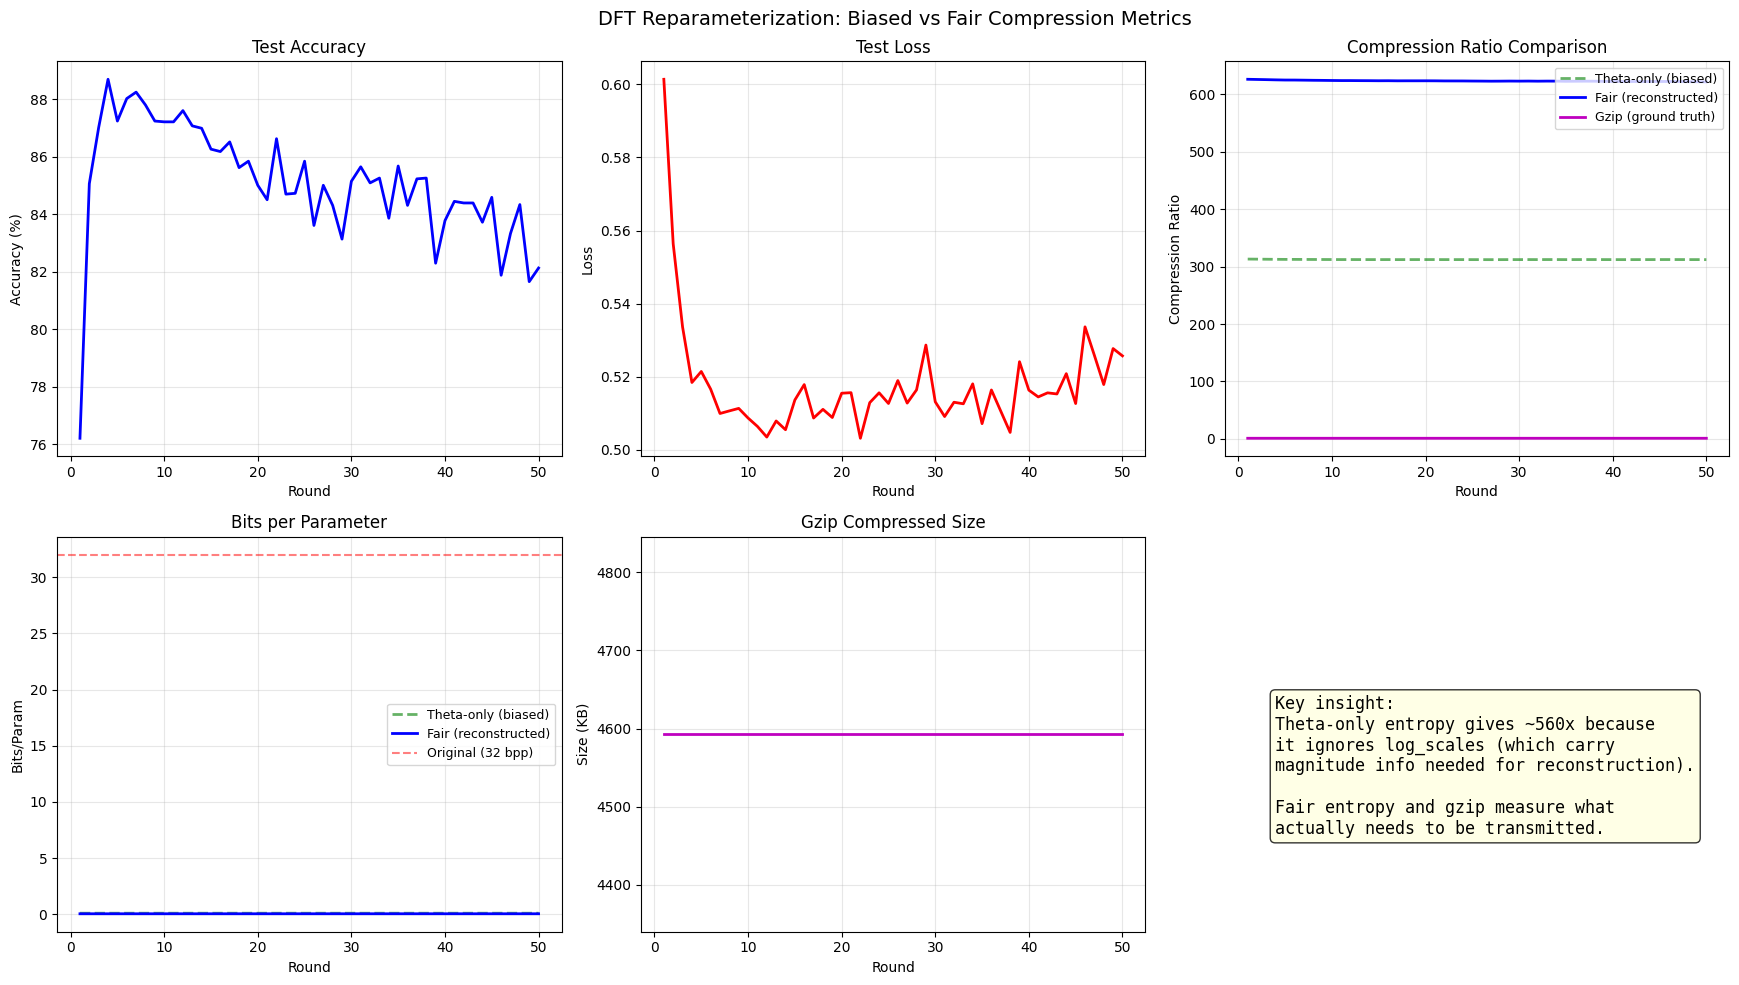

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

rounds = history['round']

axes[0, 0].plot(rounds, [a*100 for a in history['accuracy']], 'b-', lw=2)
axes[0, 0].set_xlabel('Round'); axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Test Accuracy'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(rounds, history['loss'], 'r-', lw=2)
axes[0, 1].set_xlabel('Round'); axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Test Loss'); axes[0, 1].grid(True, alpha=0.3)

ax = axes[0, 2]
ax.plot(rounds, history['cr_theta_only'], 'g--', lw=2, label='Theta-only (biased)', alpha=0.6)
ax.plot(rounds, history['cr_fair'], 'b-', lw=2, label='Fair (reconstructed)')
ax.plot(rounds, history['cr_gzip'], 'm-', lw=2, label='Gzip (ground truth)')
ax.set_xlabel('Round'); ax.set_ylabel('Compression Ratio')
ax.set_title('Compression Ratio Comparison'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(rounds, history['bpp_theta_only'], 'g--', lw=2, label='Theta-only (biased)', alpha=0.6)
ax.plot(rounds, history['bpp_fair'], 'b-', lw=2, label='Fair (reconstructed)')
ax.axhline(y=32, color='r', ls='--', alpha=0.5, label='Original (32 bpp)')
ax.set_xlabel('Round'); ax.set_ylabel('Bits/Param')
ax.set_title('Bits per Parameter'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Gzip sizes
ax = axes[1, 1]
ax.plot(rounds, [estimate_gzip_compression(global_model)['compressed_size_kb']] * len(rounds),
        'm-', lw=2)
ax.set_xlabel('Round'); ax.set_ylabel('Size (KB)')
ax.set_title('Gzip Compressed Size'); ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')
axes[1, 2].text(0.1, 0.6, "Key insight:\n"
    "Theta-only entropy gives ~560x because\n"
    "it ignores log_scales (which carry\n"
    "magnitude info needed for reconstruction).\n\n"
    "Fair entropy and gzip measure what\n"
    "actually needs to be transmitted.",
    fontsize=12, verticalalignment='top', family='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('DFT Reparameterization: Biased vs Fair Compression Metrics', fontsize=14)
plt.tight_layout(); plt.savefig('dft_covid19_results_fixed.png', dpi=150); plt.show()

## 10. Final Results

In [17]:
final_loss, final_acc = evaluate_model(global_model, x_test_combined, y_test_combined)
theta_stats = estimate_theta_only_entropy(global_model)
fair_stats = estimate_fair_compression(global_model)
gzip_stats = estimate_gzip_compression(global_model)

print("\n" + "="*70)
print("FINAL RESULTS -- DFT REPARAMETERIZATION (CORRECTED)")
print("="*70)

print(f"\nModel Performance:")
print(f"  Accuracy:  {final_acc*100:.2f}%")
print(f"  Loss:      {final_loss:.4f}")

print(f"\n{'Metric':<30} {'Theta-Only (biased)':<22} {'Fair (corrected)':<22} {'Gzip (ground truth)':<22}")
print("-" * 96)
print(f"{'CR':<30} {theta_stats['compression_ratio']:<22.2f} {fair_stats['compression_ratio']:<22.2f} {gzip_stats['compression_ratio']:<22.2f}")
print(f"{'Bits/param':<30} {theta_stats['bits_per_param']:<22.4f} {fair_stats['bits_per_param']:<22.4f} {'N/A':<22}")
print(f"{'Compressed KB':<30} {theta_stats['compressed_size_kb']:<22.2f} {fair_stats['compressed_size_kb']:<22.2f} {gzip_stats['compressed_size_kb']:<22.2f}")
print(f"{'BW Reduction %':<30} {(1-1/theta_stats['compression_ratio'])*100:<22.1f} {(1-1/fair_stats['compression_ratio'])*100:<22.1f} {gzip_stats['bandwidth_reduction']:<22.1f}")

print(f"\n  Why the gap?")
print(f"  Theta-only ignores {sum(tf.size(l.log_scales).numpy() for l in global_model.layers if hasattr(l, 'log_scales')):,} "
      f"log_scale params + biases that must also be transmitted.")
print(f"  Fair metric measures entropy on the actual spatial-domain weights.")


FINAL RESULTS -- DFT REPARAMETERIZATION (CORRECTED)

Model Performance:
  Accuracy:  82.13%
  Loss:      0.5257

Metric                         Theta-Only (biased)    Fair (corrected)       Gzip (ground truth)   
------------------------------------------------------------------------------------------------
CR                             312.20                 621.74                 1.07                  
Bits/param                     0.1025                 0.0515                 N/A                   
Compressed KB                  7.85                   7.89                   4592.70               
BW Reduction %                 99.7                   99.8                   6.3                   

  Why the gap?
  Theta-only ignores 627,552 log_scale params + biases that must also be transmitted.
  Fair metric measures entropy on the actual spatial-domain weights.


In [18]:
print("\n" + "="*70)
print("COMPARISON: DFT vs ENTROPY-PENALIZED (Fair Metrics)")
print("="*70)

your_accuracy = 83.11
your_compression = 3.94
your_bandwidth_reduction = 72.9

dft_acc = final_acc * 100
dft_cr_fair = fair_stats['compression_ratio']
dft_cr_gzip = gzip_stats['compression_ratio']
dft_bw_fair = (1 - 1/dft_cr_fair) * 100
dft_bw_gzip = gzip_stats['bandwidth_reduction']

print(f"\n{'Metric':<25} {'Entropy-Penalized':<20} {'DFT (fair)':<20} {'DFT (gzip)':<20}")
print("-" * 85)
print(f"{'Accuracy (%)':<25} {your_accuracy:<20.2f} {dft_acc:<20.2f} {dft_acc:<20.2f}")
print(f"{'Compression Ratio':<25} {your_compression:<20.2f} {dft_cr_fair:<20.2f} {dft_cr_gzip:<20.2f}")
print(f"{'BW Reduction (%)':<25} {your_bandwidth_reduction:<20.1f} {dft_bw_fair:<20.1f} {dft_bw_gzip:<20.1f}")

print(f"\nNote: The original 561x figure was theta-only (biased). Fair comparison")
print(f"uses reconstructed weights or gzip on all transmittable parameters.")


COMPARISON: DFT vs ENTROPY-PENALIZED (Fair Metrics)

Metric                    Entropy-Penalized    DFT (fair)           DFT (gzip)          
-------------------------------------------------------------------------------------
Accuracy (%)              83.11                82.13                82.13               
Compression Ratio         3.94                 621.74               1.07                
BW Reduction (%)          72.9                 99.8                 6.3                 

Note: The original 561x figure was theta-only (biased). Fair comparison
uses reconstructed weights or gzip on all transmittable parameters.


In [19]:
results = {
    'dataset': 'COVID-19_CT_scans',
    'method': 'DFT_reparameterization_CORRECTED',
    'final_accuracy': float(final_acc),
    'final_loss': float(final_loss),
    'metrics': {
        'theta_only_biased': {
            'compression_ratio': float(theta_stats['compression_ratio']),
            'bits_per_param': float(theta_stats['bits_per_param']),
            'compressed_size_kb': float(theta_stats['compressed_size_kb']),
        },
        'fair_reconstructed': {
            'compression_ratio': float(fair_stats['compression_ratio']),
            'bits_per_param': float(fair_stats['bits_per_param']),
            'compressed_size_kb': float(fair_stats['compressed_size_kb']),
        },
        'gzip_ground_truth': {
            'compression_ratio': float(gzip_stats['compression_ratio']),
            'compressed_size_kb': float(gzip_stats['compressed_size_kb']),
            'bandwidth_reduction': float(gzip_stats['bandwidth_reduction']),
        },
    },
    'config': {
        'image_size': IMAGE_SIZE, 'lambda_rate': LAMBDA_RATE,
        'temperature': TEMPERATURE, 'alpha': ALPHA,
        'num_rounds': NUM_ROUNDS, 'num_clients': NUM_CLIENTS,
        'num_epochs': NUM_EPOCHS,
        'teacher_weights': TEACHER_WEIGHTS.tolist()
    },
    'history': {k: [float(v) if isinstance(v, (float, np.floating)) else v for v in vals]
                for k, vals in history.items()},
}

with open('dft_covid19_results_fixed.json', 'w') as f:
    json.dump(results, f, indent=2)

global_model.save_weights('dft_covid19_model_weights_fixed.weights.h5')

print("Results saved:")
print("  - dft_covid19_results_fixed.json")
print("  - dft_covid19_model_weights_fixed.weights.h5")
print("  - dft_covid19_results_fixed.png")

Results saved:
  - dft_covid19_results_fixed.json
  - dft_covid19_model_weights_fixed.weights.h5
  - dft_covid19_results_fixed.png
